In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD


CSV_PATH = "data/city_lifestyle_dataset.csv"  
OUT_FILE = ("runcatedSVD.csv")

In [ ]:
df.

In [2]:
df = pd.read_csv(CSV_PATH)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
display(df.head())

Shape: (300, 10)
Columns: ['city_name', 'country', 'population_density', 'avg_income', 'internet_penetration', 'avg_rent', 'air_quality_index', 'public_transport_score', 'happiness_score', 'green_space_ratio']


,city_name,country,population_density,avg_income,internet_penetration,avg_rent,air_quality_index,public_transport_score,happiness_score,green_space_ratio
0,Old Vista,Europe,2775,3850,86.4,1310,43,52.0,8.5,23.8
1,Beachport,Europe,3861,3700,78.1,1330,42,62.8,8.1,33.1
2,Valleyborough,Europe,2562,4310,80.1,1330,39,73.2,8.5,40.2
3,City,Europe,3192,3970,81.2,1480,60,49.2,8.5,43.6
4,Falls,Europe,3496,4320,100.0,1510,64,93.7,8.5,42.5


In [3]:
# On exclut les identifiants / catégorielles
drop_cols = [c for c in ["city_name", "country", "region"] if c in df.columns]
X = df.drop(columns=drop_cols)

print("Numeric features used:", X.columns.tolist())
display(X.describe().T)

Numeric features used: ['population_density', 'avg_income', 'internet_penetration', 'avg_rent', 'air_quality_index', 'public_transport_score', 'happiness_score', 'green_space_ratio']


,count,mean,std,min,25%,50%,75%,max
population_density,300.0,3944.843333,2982.566777,100.0,1830.000,3083.5,4823.750,14427.0
avg_income,300.0,2827.200000,1201.163939,480.0,1907.500,2810.0,3752.500,5720.0
internet_penetration,300.0,74.305333,17.014492,34.0,64.400,75.0,87.225,100.0
avg_rent,300.0,1002.766667,456.282066,170.0,640.000,990.0,1332.500,2430.0
air_quality_index,300.0,71.246667,25.344961,22.0,54.000,67.5,86.000,146.0
public_transport_score,300.0,55.717333,14.712549,15.0,46.075,54.7,64.200,95.0
happiness_score,300.0,6.644000,1.685864,2.5,5.300,6.9,8.500,8.5
green_space_ratio,300.0,33.993333,9.434067,2.0,28.225,34.7,40.400,58.0


In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
svd = TruncatedSVD(n_components=2, random_state=42)
X_2d = svd.fit_transform(X_scaled)

# Variance expliquée 
explained = svd.explained_variance_ratio_
print("Explained variance ratio:", explained)
print("Total explained variance (2D):", float(np.sum(explained)))

Explained variance ratio: [0.53805804 0.25833116]
Total explained variance (2D): 0.7963892000125797


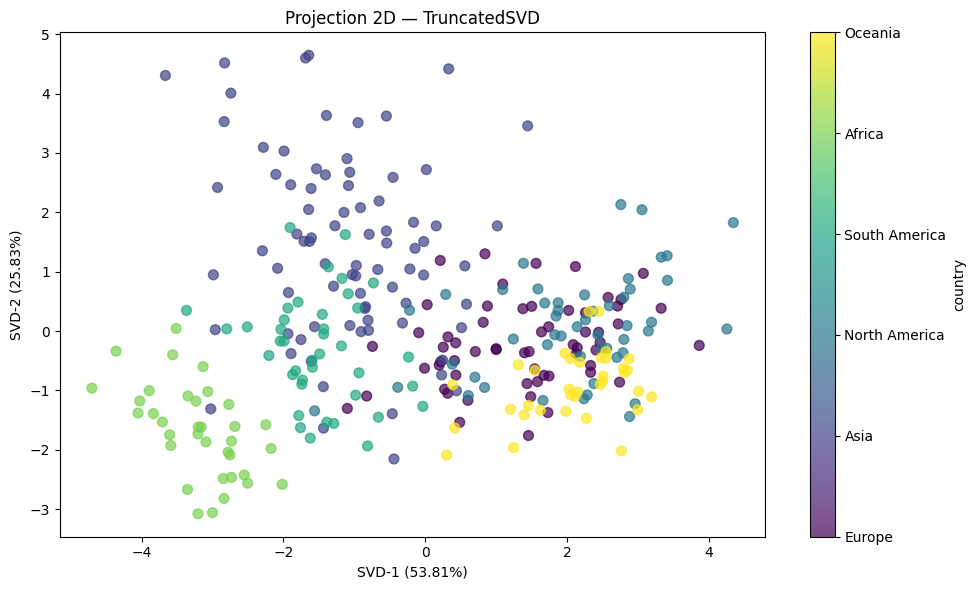

In [5]:
color_col = "country"


plt.figure(figsize=(10, 6))

cats = df[color_col].astype(str)
# mapping catégories -> ints pour colormap
cat_codes, uniques = pd.factorize(cats)
sc = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=cat_codes, alpha=0.7, s=50)
cbar = plt.colorbar(sc)
cbar.set_ticks(range(len(uniques)))
cbar.set_ticklabels(list(uniques))
cbar.set_label(color_col)


plt.xlabel(f"SVD-1 ({explained[0]:.2%})")
plt.ylabel(f"SVD-2 ({explained[1]:.2%})")
plt.title("Projection 2D — TruncatedSVD")
plt.tight_layout()
plt.show()


In [6]:
df_2d = pd.DataFrame({
    "svd1": X_2d[:, 0],
    "svd2": X_2d[:, 1],
})
df_2d

,svd1,svd2
0,1.743192,0.071251
1,1.641493,-0.014981
2,2.411046,-0.320204
3,1.748150,-0.758528
4,3.078707,0.971714
...,...,...
295,3.196949,-1.111666
296,2.797767,-0.627874
297,2.472865,-0.901853
298,2.276399,-1.469961


In [8]:
df_export = pd.concat([df[["city_name", "country", ""]].reset_index(drop=True), df_2d], axis=1)
df_export

KeyError: "['region'] not in index"